In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../src'))
from utils import prepare_text_data, extract_stylistic_features

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch a correr no dispositivo: {device}")

PyTorch a correr no dispositivo: cuda


In [7]:
# Carregar o dataset
# Leitura robusta para ficheiros com vírgulas no texto (não escapadas)
rows = []
with open('../data/dataset.csv', 'r', encoding='utf-8', errors='ignore') as f:
    next(f)  # ignorar header
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',', 1)  # separa apenas no 1º separador
        if len(parts) == 2:
            rows.append(parts)

df = pd.DataFrame(rows, columns=['label', 'text']).dropna()

textos = df['text'].tolist()
labels = df['label'].tolist()

# 2. Usar o mesmo pipeline de features combinadas do T2
# Word TF-IDF (3000) + Char TF-IDF (3000) + 13 features estilisticas
# Limpar labels/classes (evita classes com 1 amostra que quebram o stratify)
valid_classes = {"OpenAI", "Anthropic", "Meta", "Google", "Human"}
textos_ok, labels_ok = [], []

for i, t in enumerate(textos):
    t = str(t).strip()
    l = str(labels[i]).strip()

    # prioridade: classe no fim do texto (ex.: "...;OpenAI")
    cls = t.rsplit(";", 1)[-1].strip() if ";" in t else ""
    txt = t.rsplit(";", 1)[0].strip() if ";" in t else t

    # fallback: tentar extrair da coluna label
    if cls not in valid_classes:
        cls2 = l.rsplit(";", 1)[-1].strip() if ";" in l else l
        if cls2 in valid_classes:
            cls = cls2

    if cls in valid_classes and txt:
        textos_ok.append(txt)
        labels_ok.append(cls)

# remover classes demasiado raras para stratified split
counts = pd.Series(labels_ok).value_counts()
valid_after_count = set(counts[counts >= 3].index)  # robusto para split treino/val/test

textos_final = [x for x, y in zip(textos_ok, labels_ok) if y in valid_after_count]
labels_final = [y for y in labels_ok if y in valid_after_count]

X_train, Y_train_oh, X_val, Y_val_oh, X_test, Y_test_oh, transformers, encoder = prepare_text_data(
    textos_final, labels_final,
    max_features=3000,
    char_features=3000,
    test_size=0.2,
    val_size=0.1,
    use_stratify=True,
    ngram_range=(1, 2)
)

# 3. Converter One-Hot para indices (PyTorch usa CrossEntropyLoss com indices)
y_train = np.argmax(Y_train_oh, axis=1)
y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)

# 4. Converter para Tensores PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# 5. DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

class_names = encoder.categories_[0]
print(f"Classes: {class_names}")
print(f"Train: {X_train_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")
print(f"Total features: {X_train_t.shape[1]}")

Classes: ['Anthropic' 'Google' 'Meta' 'OpenAI']
Train: torch.Size([1310, 6013]) | Val: torch.Size([187, 6013]) | Test: torch.Size([375, 6013])
Total features: 6013


In [8]:
class DetectorIADeep(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DetectorIADeep, self).__init__()
        self.net = nn.Sequential(
            # Camada 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),          # BatchNorm: estabiliza e acelera o treino
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Camada 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Camada 3
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Saida
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

input_size = X_train_t.shape[1]
num_classes = len(class_names)

model = DetectorIADeep(input_size=input_size, num_classes=num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo DNN + BatchNorm: {total_params:,} parametros")
print(model)

Modelo DNN + BatchNorm: 3,228,868 parametros
DetectorIADeep(
  (net): Sequential(
    (0): Linear(in_features=6013, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

epochs = 300
history_train_loss = []
history_val_loss = []
history_val_acc = []

best_val_loss = float('inf')
patience = 30
patience_counter = 0
best_model_path = '../best_model_pytorch.pth'

print("A iniciar o treino com DNN + BatchNorm...")
for epoch in range(epochs):
    # === TREINO ===
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    
    # === VALIDACAO ===
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    history_val_loss.append(avg_val_loss)
    history_val_acc.append(val_acc)
    
    scheduler.step(avg_val_loss)
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoca [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if patience_counter >= patience:
        print(f"Epoca [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"\nEarly Stopping na epoca {epoch+1}!")
        break

model.load_state_dict(torch.load(best_model_path, weights_only=True))
print(f"\nMelhores pesos restaurados (Val Loss: {best_val_loss:.4f})")

A iniciar o treino com DNN + BatchNorm...
Epoca [10/300] - Train Loss: 0.0454 | Val Loss: 0.6876 | Val Acc: 81.82%
Epoca [20/300] - Train Loss: 0.0175 | Val Loss: 0.6965 | Val Acc: 79.14%
Epoca [30/300] - Train Loss: 0.0109 | Val Loss: 0.6754 | Val Acc: 81.28%
Epoca [32/300] - Train Loss: 0.0094 | Val Loss: 0.6714 | Val Acc: 82.89%

Early Stopping na epoca 32!

Melhores pesos restaurados (Val Loss: 0.5161)


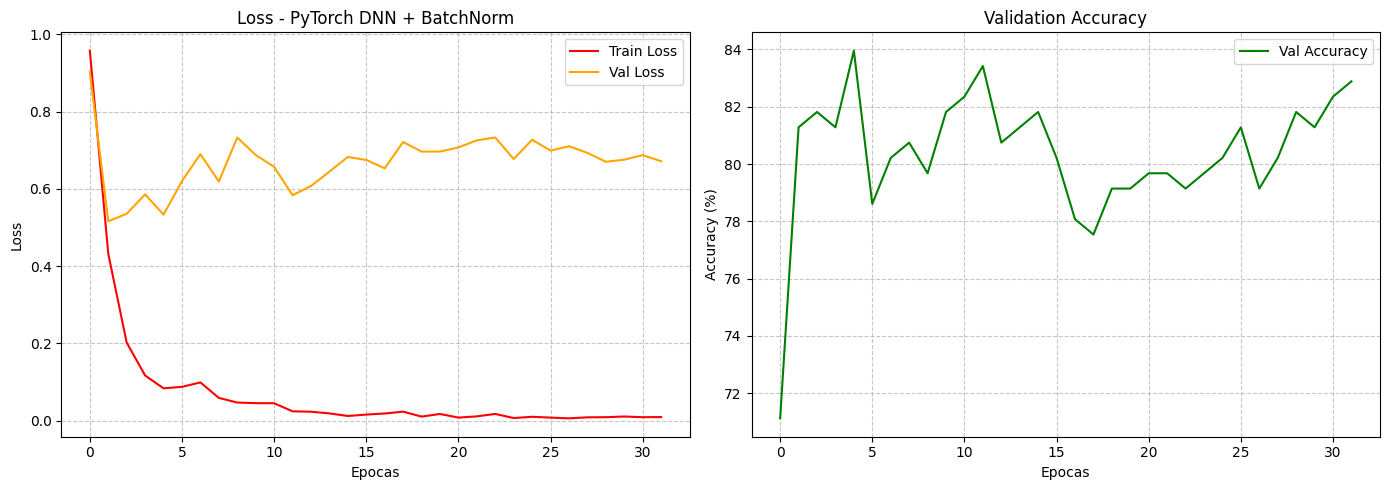

Resultados do Modelo PyTorch (DNN + BatchNorm)
  Teste Accuracy: 82.67%
  Teste Loss: 0.4687


In [10]:
# 1. Graficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_train_loss, label='Train Loss', color='red')
ax1.plot(history_val_loss, label='Val Loss', color='orange')
ax1.set_title('Loss - PyTorch DNN + BatchNorm')
ax1.set_xlabel('Epocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(history_val_acc, label='Val Accuracy', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epocas')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Avaliacao no Teste
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    test_loss = criterion(outputs, y_test_t).item()
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_test_t).sum().item()
    accuracy = 100 * correct / y_test_t.size(0)

print(f"Resultados do Modelo PyTorch (DNN + BatchNorm)")
print(f"  Teste Accuracy: {accuracy:.2f}%")
print(f"  Teste Loss: {test_loss:.4f}")

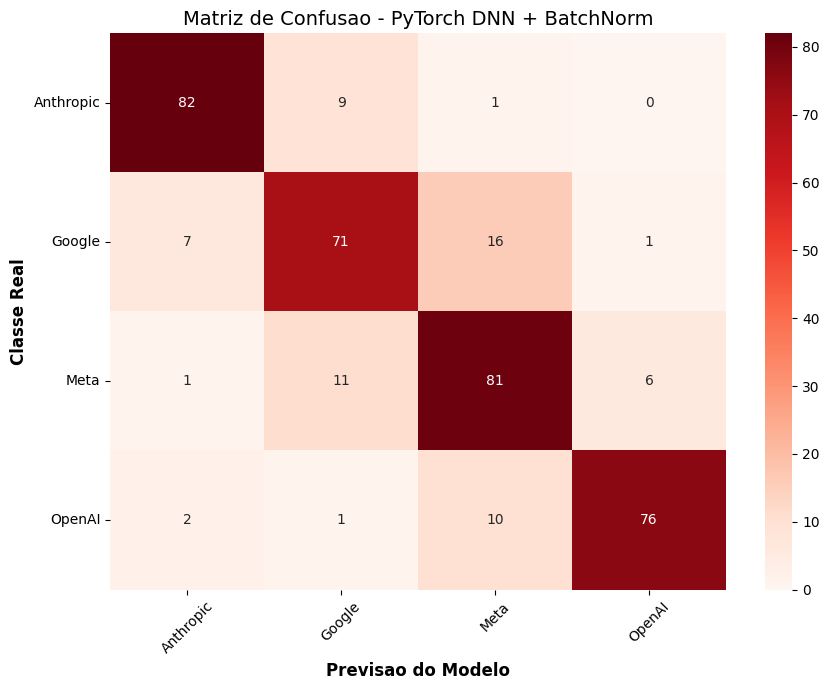


Classification Report:
              precision    recall  f1-score   support

   Anthropic       0.89      0.89      0.89        92
      Google       0.77      0.75      0.76        95
        Meta       0.75      0.82      0.78        99
      OpenAI       0.92      0.85      0.88        89

    accuracy                           0.83       375
   macro avg       0.83      0.83      0.83       375
weighted avg       0.83      0.83      0.83       375



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)

y_true = y_test_t.cpu().numpy()
y_pred = predicted.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsao do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusao - PyTorch DNN + BatchNorm', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))